# Mental Health Prescribing Analysis

## Introduction

This project analyses NHS antidepressant prescribing data across England between 2021 and 2024 using data from the NHSBSA Prescription Cost Analysis dataset.

The project investigates:
- prescribing trends over time
- regional prescribing variations
- prescribing costs
- operational cost efficiency

The aim is to generate healthcare insights using Python, exploratory data analysis, and time-series analysis techniques.

## Import Libraries

In this section, the required Python libraries for data analysis and visualisation are imported.

In [60]:
# Import Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a consistent chart style
plt.style.use('ggplot')

print("Libraries imported successfully")

Libraries imported successfully


## Load Dataset

The NHS antidepressant prescribing dataset is loaded into a Pandas DataFrame for analysis.

In [54]:
# Load the NHS prescribing dataset

drug_data = pd.read_csv("../data/BSA_ODP_PCA_REGIONAL_DRUG_SUMMARY.csv")



In [56]:
print(f"Dataset contains {drug_data.shape[0]} rows and {drug_data.shape[1]} columns.")

Dataset contains 9455 rows and 6 columns.


## Data Inspection


Initial inspection is performed to understand the dataset structure, dimensions, data types, missing values, and overall data quality.


In [53]:
# Display first 5 rows
drug_data.head()

,YEAR,YEAR_MONTH,REGION_NAME,BNF_CHEMICAL_SUBSTANCE,ITEMS,COST
0,2021,2021-01-01,EAST OF ENGLAND,Agomelatine,183,7405.37
1,2021,2021-01-01,LONDON,Agomelatine,411,18227.63
2,2021,2021-01-01,MIDLANDS,Agomelatine,252,12344.56
3,2021,2021-01-01,NORTH EAST AND YORKSHIRE,Agomelatine,366,11183.06
4,2021,2021-01-01,NORTH WEST,Agomelatine,119,4783.72


In [34]:
# Check dataset dimensions

drug_data.shape

(9455, 6)

In [35]:
# Check column data types

drug_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9455 entries, 0 to 9454
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   YEAR                    9455 non-null   int64  
 1   YEAR_MONTH              9455 non-null   int64  
 2   REGION_NAME             9455 non-null   str    
 3   BNF_CHEMICAL_SUBSTANCE  9455 non-null   str    
 4   ITEMS                   9455 non-null   int64  
 5   COST                    9455 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 443.3 KB


### Observation

The dataset contains 9,455 rows and 6 columns with no missing values detected. Data types appear appropriate for analysis, although the `YEAR_MONTH` column requires conversion to datetime format for time-series analysis.

In [61]:
# Generate summary statistics for numerical variables

drug_data.describe()

,YEAR,YEAR_MONTH,ITEMS,COST
count,9455.000000,9455.000000,9455.000000,9.455000e+03
mean,2022.431623,202249.442623,35227.665891,9.856693e+04
std,1.096446,109.390932,70594.998779,1.721329e+05
min,2021.000000,202101.000000,1.000000,1.100000e+00
25%,2021.000000,202112.000000,165.000000,6.541955e+03
50%,2022.000000,202211.000000,1741.000000,3.602232e+04
75%,2023.000000,202311.000000,24660.000000,1.103895e+05
max,2024.000000,202410.000000,491676.000000,2.721513e+06


### Summary Statistics Interpretation

The summary statistics provide an overview of antidepressant prescribing activity and prescribing costs across NHS regions between 2021 and 2024.

Key observations include:

- The dataset contains 9,455 prescribing records.
- The average prescription volume was approximately 35,228 items, although the large standard deviation indicates substantial variation in prescribing activity across drugs and regions.
- Prescription volumes ranged from 1 item to 491,676 items, suggesting that some antidepressants were prescribed far more frequently than others.
- The average prescribing cost was approximately £98,567, while the maximum recorded cost exceeded £2.7 million.
- The difference between median and maximum values for both `ITEMS` and `COST` suggests the presence of highly prescribed and high-cost antidepressant medications.

In [37]:
# Checking for missing values

drug_data.isnull().sum()

YEAR                      0
YEAR_MONTH                0
REGION_NAME               0
BNF_CHEMICAL_SUBSTANCE    0
ITEMS                     0
COST                      0
dtype: int64

### Missing Values Check

The missing values check confirms whether any columns contain null values. This helps assess whether data imputation or removal is required before analysis.

In [38]:
# Duplicate Rows

drug_data.duplicated().sum()

np.int64(0)

### Duplicate Records Check

The duplicate check confirms whether repeated records exist in the dataset. No duplicate records were identified, meaning each row represents a unique prescribing record.

## Data Cleaning

The dataset was reviewed for missing values, duplicate records, and appropriate data types.

Although no missing values or duplicate records were identified, the `YEAR_MONTH` column required conversion from numeric format into datetime format to support monthly trend and time-series analysis.

## Feature Engineering

Additional time-based features were created from the `YEAR_MONTH` column to support monthly, quarterly, seasonal, and time-series analysis.

These features help make the dataset more useful for trend analysis and reporting.

In [62]:
# Convert YEAR_MONTH from numeric YYYYMM format to datetime format

drug_data['YEAR_MONTH'] = pd.to_datetime(
    drug_data['YEAR_MONTH'].astype(str),
    format='%Y%m'
)

# Check datatype
drug_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9455 entries, 0 to 9454
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   YEAR                    9455 non-null   int64         
 1   YEAR_MONTH              9455 non-null   datetime64[us]
 2   REGION_NAME             9455 non-null   str           
 3   BNF_CHEMICAL_SUBSTANCE  9455 non-null   str           
 4   ITEMS                   9455 non-null   int64         
 5   COST                    9455 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 443.3 KB


### Observation

The `YEAR_MONTH` column was successfully converted into datetime format, enabling time-series analysis and trend exploration.

In [63]:
# Create additional time-based features for trend analysis

drug_data['Month'] = drug_data['YEAR_MONTH'].dt.month
drug_data['Month_Name'] = drug_data['YEAR_MONTH'].dt.month_name()
drug_data['Quarter'] = drug_data['YEAR_MONTH'].dt.quarter

drug_data.head()

,YEAR,YEAR_MONTH,REGION_NAME,BNF_CHEMICAL_SUBSTANCE,ITEMS,COST,Month,Month_Name,Quarter
0,2021,2021-01-01,EAST OF ENGLAND,Agomelatine,183,7405.37,1,January,1
1,2021,2021-01-01,LONDON,Agomelatine,411,18227.63,1,January,1
2,2021,2021-01-01,MIDLANDS,Agomelatine,252,12344.56,1,January,1
3,2021,2021-01-01,NORTH EAST AND YORKSHIRE,Agomelatine,366,11183.06,1,January,1
4,2021,2021-01-01,NORTH WEST,Agomelatine,119,4783.72,1,January,1


## Exploratory Data Analysis

Exploratory analysis is performed to identify prescribing patterns, high-volume medications, and prescribing cost behaviour.

In [ ]:
# Top prescribed antidepressants by total items

top_drugs = (
    drug_data.groupby('BNF_CHEMICAL_SUBSTANCE')['ITEMS']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_drugs

BNF_CHEMICAL_SUBSTANCE
Sertraline hydrochloride       85402251
Amitriptyline hydrochloride    59272937
Citalopram hydrobromide        52891620
Mirtazapine                    46335570
Fluoxetine hydrochloride       28211759
Venlafaxine                    21447209
Duloxetine hydrochloride       14262656
Escitalopram                    6580386
Paroxetine hydrochloride        4886615
Trazodone hydrochloride         4861813
Name: ITEMS, dtype: int64

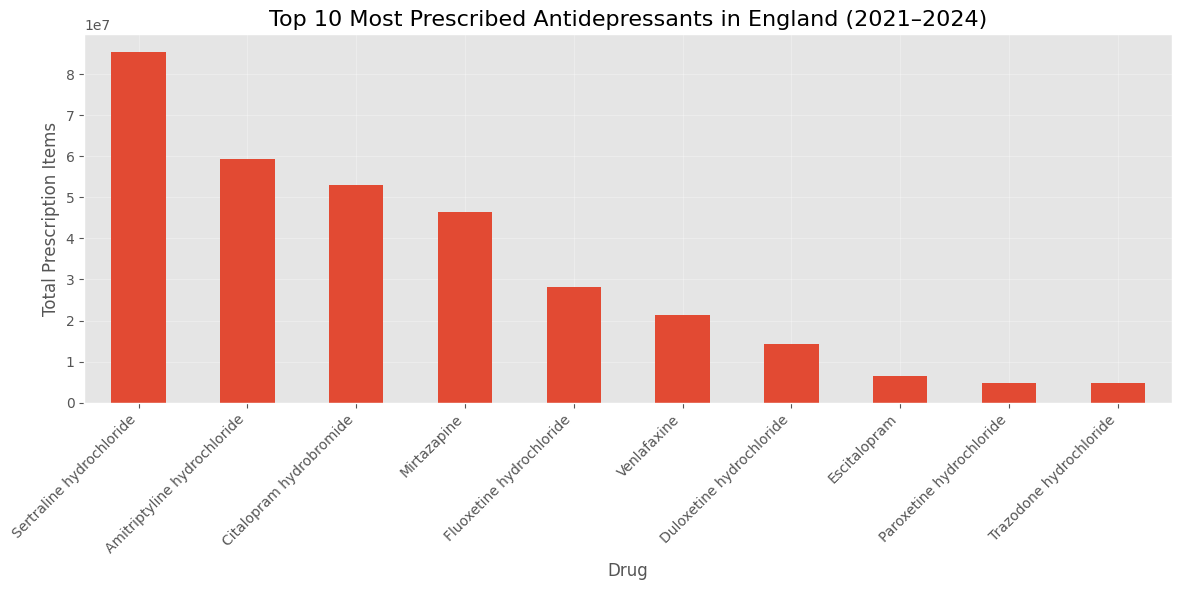

In [74]:
# Plot top prescribed antidepressants

plt.figure(figsize=(12,6))

top_drugs.plot(kind='bar')

plt.title('Top 10 Most Prescribed Antidepressants in England (2021–2024)', fontsize=16)
plt.xlabel('Drug', fontsize=12)
plt.ylabel('Total Prescription Items', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("../visuals/top_prescribed_antidepressants.png")

plt.show()

### Interpretation

Sertraline hydrochloride recorded the highest prescribing volume during the study period, suggesting widespread usage across NHS regions.

Amitriptyline hydrochloride and Citalopram hydrobromide also demonstrated consistently high prescribing activity, indicating significant antidepressant demand across England.

## Prescribing Cost Analysis

In [42]:
# Top antidepressants by total prescribing cost

top_cost_drugs = (
    drug_data.groupby('BNF_CHEMICAL_SUBSTANCE')['COST']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cost_drugs

BNF_CHEMICAL_SUBSTANCE
Sertraline hydrochloride       2.056530e+08
Venlafaxine                    1.503813e+08
Amitriptyline hydrochloride    9.273951e+07
Fluoxetine hydrochloride       8.143143e+07
Citalopram hydrobromide        7.522518e+07
Mirtazapine                    6.227576e+07
Duloxetine hydrochloride       5.487333e+07
Vortioxetine                   2.859020e+07
Trimipramine maleate           2.567658e+07
Tranylcypromine sulfate        2.179562e+07
Name: COST, dtype: float64

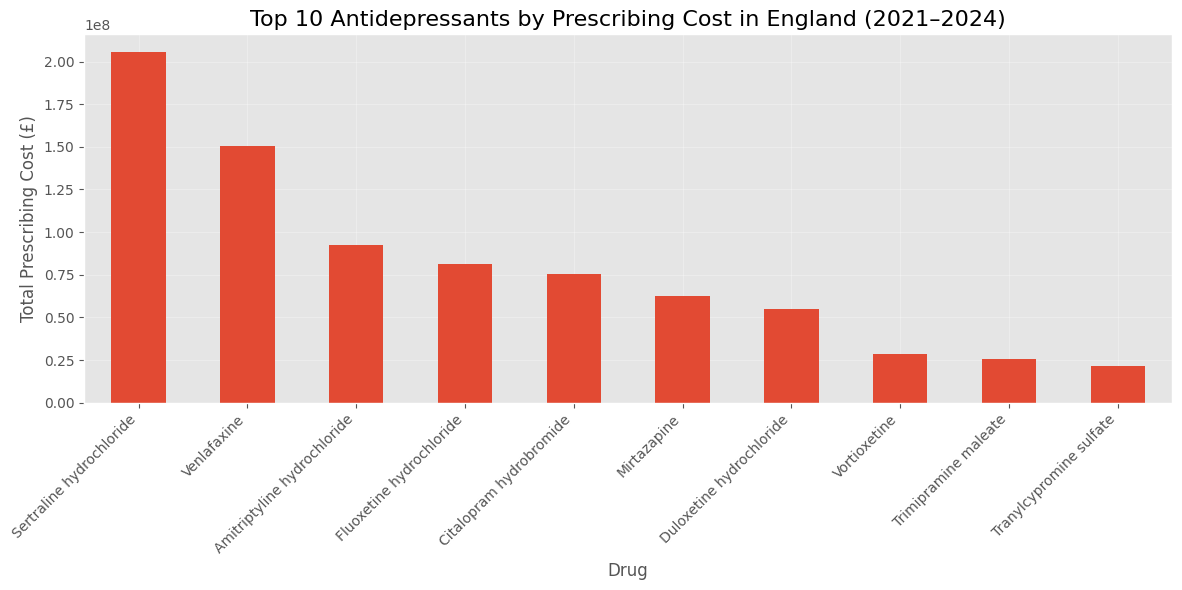

In [75]:
# Plot highest cost antidepressants

plt.figure(figsize=(12,6))

top_cost_drugs.plot(kind='bar')

plt.title('Top 10 Antidepressants by Prescribing Cost in England (2021–2024)', fontsize=16)
plt.xlabel('Drug', fontsize=12)
plt.ylabel('Total Prescribing Cost (£)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../visuals/top_cost_antidepressants.png")

plt.show()

### Interpretation

The prescribing cost analysis shows that the most prescribed antidepressants are not always the most expensive.

Venlafaxine appears as a high-cost medication despite not being the highest-volume drug, suggesting that medication price, prescribing patterns, or treatment complexity may influence total prescribing cost.

## Regional Analysis

Regional analysis explores differences in antidepressant prescribing activity across NHS regions in England.


In [44]:
# Total prescription items by NHS region

regional_items = (
    drug_data.groupby('REGION_NAME')['ITEMS']
    .sum()
    .sort_values(ascending=False)
)

regional_items

REGION_NAME
NORTH EAST AND YORKSHIRE    72090463
MIDLANDS                    62669553
NORTH WEST                  49786016
SOUTH EAST                  41867132
EAST OF ENGLAND             38431318
LONDON                      35896285
SOUTH WEST                  32336814
Name: ITEMS, dtype: int64

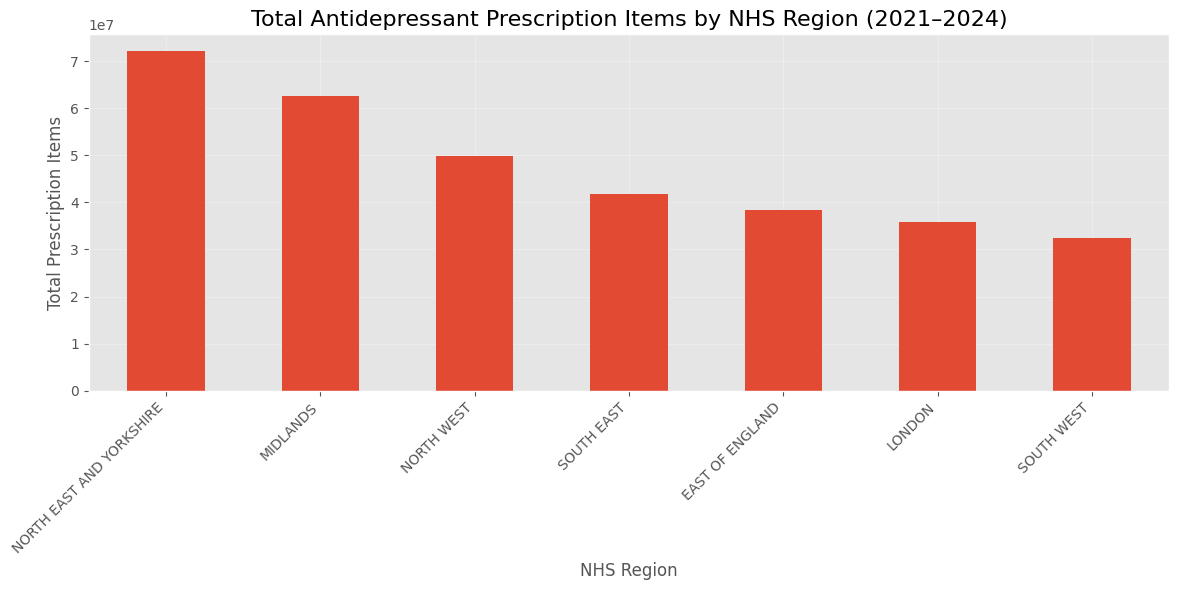

In [76]:
# Plot prescribing activity by NHS region

plt.figure(figsize=(12,6))

regional_items.plot(kind='bar')

plt.title('Total Antidepressant Prescription Items by NHS Region (2021–2024)', fontsize=16)
plt.xlabel('NHS Region', fontsize=12)
plt.ylabel('Total Prescription Items', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../visuals/regional_prescribing_items.png")

plt.show()

### Interpretation

North East and Yorkshire recorded the highest antidepressant prescribing activity during the study period, followed by the Midlands and North West.

Regional variation may reflect differences in population size, demographics, healthcare demand, socioeconomic factors, and prescribing practices across NHS regions.

## Time-Series Analysis


This section explores monthly antidepressant prescribing trends over time to identify changes in prescribing behaviour and healthcare demand between 2021 and 2024.

In [46]:
# Monthly prescribing trend

monthly_trend = (
    drug_data.groupby('YEAR_MONTH')['ITEMS']
    .sum()
)

monthly_trend.head()

YEAR_MONTH
2021-01-01    6711605
2021-02-01    6337714
2021-03-01    7129148
2021-04-01    6895434
2021-05-01    6597509
Name: ITEMS, dtype: int64

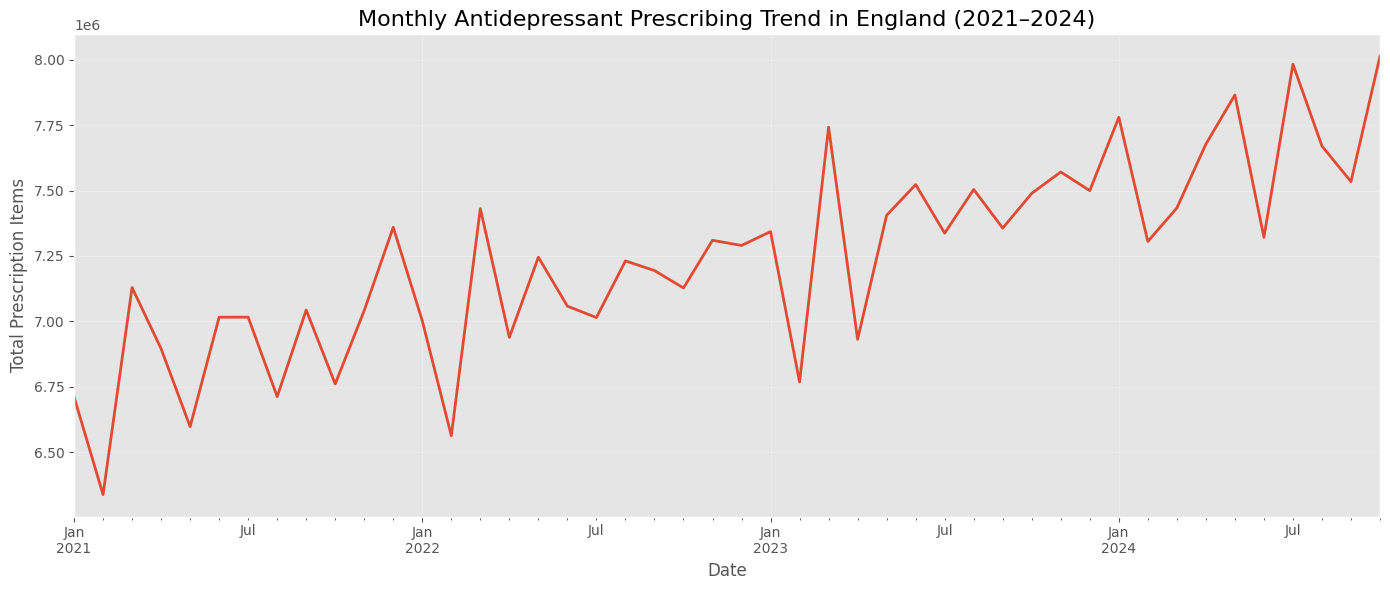

In [77]:
# Plot monthly prescribing trend

plt.figure(figsize=(14,6))

monthly_trend.plot(linewidth=2)

plt.title('Monthly Antidepressant Prescribing Trend in England (2021–2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Prescription Items', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../visuals/monthly_prescribing_trend.png")

plt.show()

### Interpretation

The monthly prescribing trend shows a general increase in antidepressant prescribing volumes between 2021 and 2024.

This suggests rising demand for antidepressant medication and may reflect increased mental health service utilisation, changes in prescribing behaviour, or wider population health needs.

## Top 5 Antidepressant Trends Over Time

This section compares monthly prescribing trends for the five most prescribed antidepressant medications.

In [70]:
# Identify top 5 antidepressants by total prescription items

top_5_drugs = (
    drug_data.groupby('BNF_CHEMICAL_SUBSTANCE')['ITEMS']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_5_drugs

Index(['Sertraline hydrochloride', 'Amitriptyline hydrochloride',
       'Citalopram hydrobromide', 'Mirtazapine', 'Fluoxetine hydrochloride'],
      dtype='str', name='BNF_CHEMICAL_SUBSTANCE')

In [71]:
# Filter data for top 5 antidepressants

top_5_data = drug_data[drug_data['BNF_CHEMICAL_SUBSTANCE'].isin(top_5_drugs)]

# Group by month and drug
top_5_monthly_trend = (
    top_5_data.groupby(['YEAR_MONTH', 'BNF_CHEMICAL_SUBSTANCE'])['ITEMS']
    .sum()
    .unstack()
)

top_5_monthly_trend.head()

BNF_CHEMICAL_SUBSTANCE,Amitriptyline hydrochloride,Citalopram hydrobromide,Fluoxetine hydrochloride,Mirtazapine,Sertraline hydrochloride
YEAR_MONTH,,,,,
2021-01-01,1219610,1177855,596722,910085,1620265
2021-02-01,1154171,1101852,560797,864894,1530749
2021-03-01,1299017,1232369,630333,972691,1735443
2021-04-01,1253506,1191146,608945,937918,1678799
2021-05-01,1194095,1137869,581974,893785,1616528


<Figure size 1400x600 with 0 Axes>

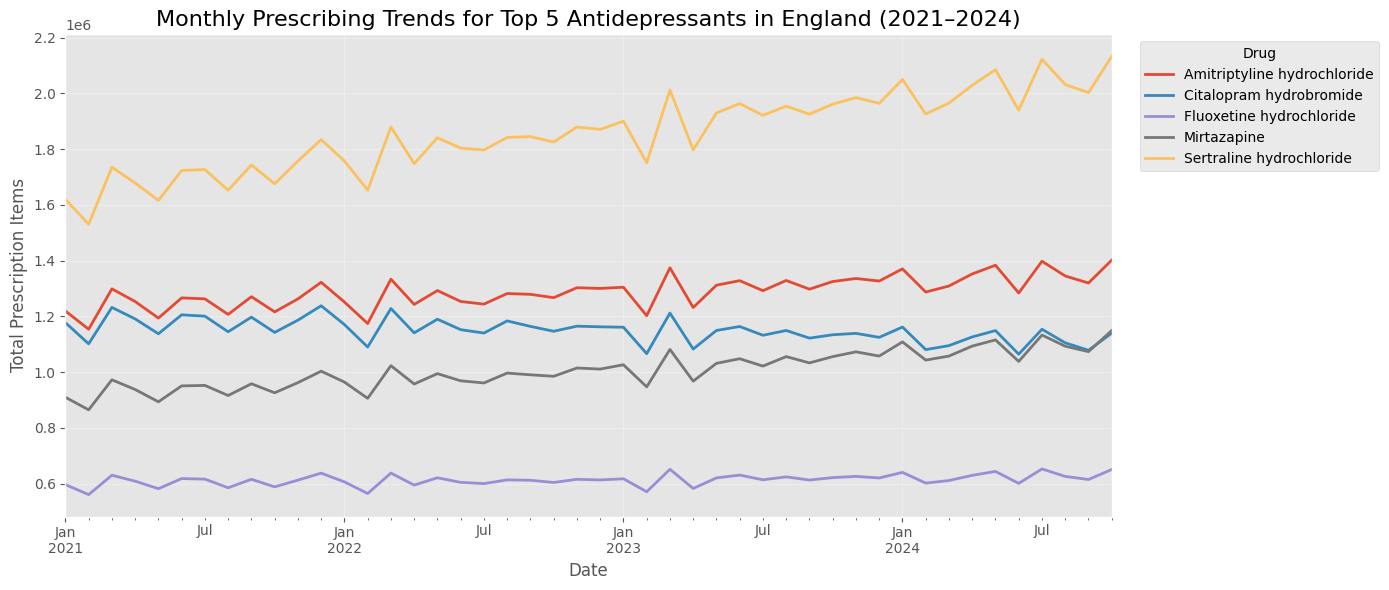

In [81]:
# Plot monthly prescribing trends for top 5 antidepressants

plt.figure(figsize=(14,6))

top_5_monthly_trend.plot(
    linewidth=2,
    figsize=(14,6)
)

plt.title(
    'Monthly Prescribing Trends for Top 5 Antidepressants in England (2021–2024)',
    fontsize=16
)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Prescription Items', fontsize=12)

plt.legend(
    title='Drug',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../visuals/top_5_drug_trends.png")

plt.show()

### Interpretation

Sertraline hydrochloride consistently recorded the highest prescribing volume across the study period and showed a steady upward trend between 2021 and 2024.

Amitriptyline hydrochloride and Citalopram hydrobromide also demonstrated relatively stable but increasing prescribing patterns over time.

Although all five antidepressants showed fluctuations in monthly prescribing activity, the overall trend suggests increasing antidepressant demand across England.

## Cost Efficiency Analysis

Cost efficiency analysis was performed to compare prescribing volumes against prescribing costs over time.

In [48]:
# Monthly prescribing cost trend

monthly_cost_trend = (
    drug_data.groupby('YEAR_MONTH')['COST']
    .sum()
)

monthly_cost_trend.head()

YEAR_MONTH
2021-01-01    30211076.90
2021-02-01    28478445.17
2021-03-01    31933609.64
2021-04-01    24695554.55
2021-05-01    23672108.18
Name: COST, dtype: float64

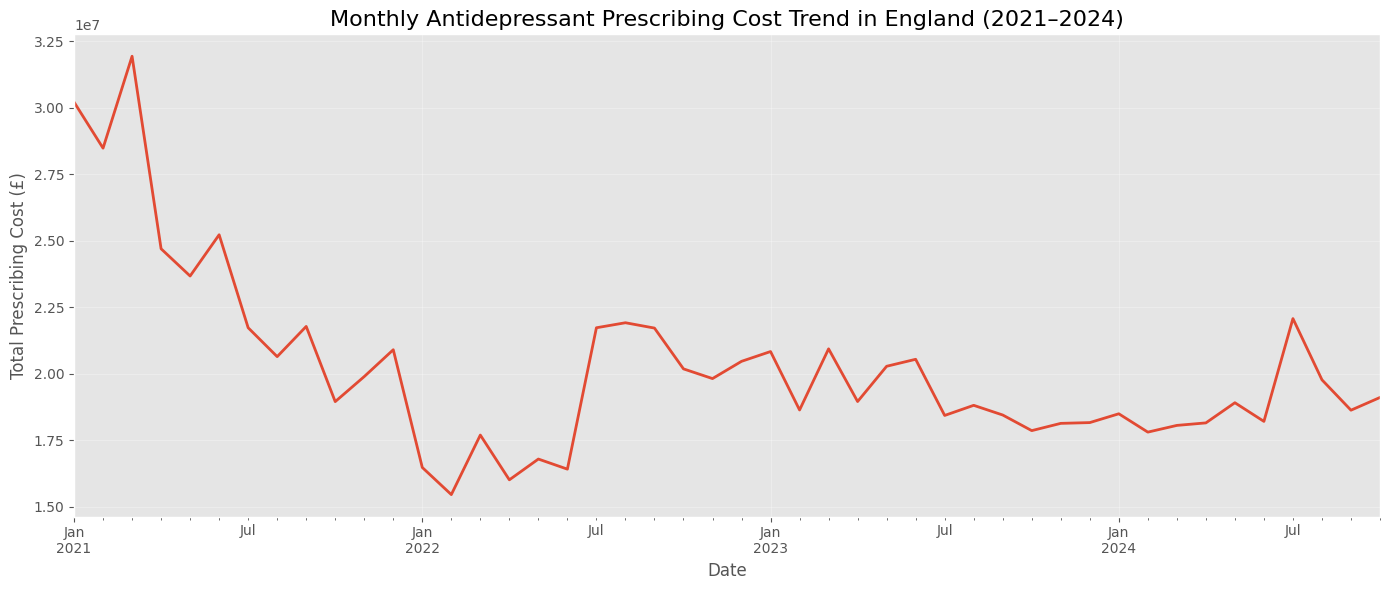

In [79]:
# Plot monthly prescribing cost trend

plt.figure(figsize=(14,6))

monthly_cost_trend.plot(linewidth=2)

plt.title('Monthly Antidepressant Prescribing Cost Trend in England (2021–2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Prescribing Cost (£)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../visuals/monthly_cost_trend.png")

plt.show()

### Interpretation

The monthly prescribing cost trend shows that total antidepressant prescribing costs generally declined over time, despite the increase in prescription volumes.

This may suggest improved prescribing cost efficiency, changes in medication pricing, or increased use of lower-cost generic medications.

In [50]:
# Combine monthly items and costs

monthly_summary = (
    drug_data.groupby('YEAR_MONTH')[['ITEMS', 'COST']]
    .sum()
)

monthly_summary.head()

,ITEMS,COST
YEAR_MONTH,,
2021-01-01,6711605,30211076.90
2021-02-01,6337714,28478445.17
2021-03-01,7129148,31933609.64
2021-04-01,6895434,24695554.55
2021-05-01,6597509,23672108.18


In [51]:
# Calculate average cost per prescription item

monthly_summary['Cost_Per_Item'] = (
    monthly_summary['COST'] / monthly_summary['ITEMS']
)

monthly_summary.head()

,ITEMS,COST,Cost_Per_Item
YEAR_MONTH,,,
2021-01-01,6711605,30211076.90,4.501319
2021-02-01,6337714,28478445.17,4.493489
2021-03-01,7129148,31933609.64,4.479302
2021-04-01,6895434,24695554.55,3.581436
2021-05-01,6597509,23672108.18,3.588037


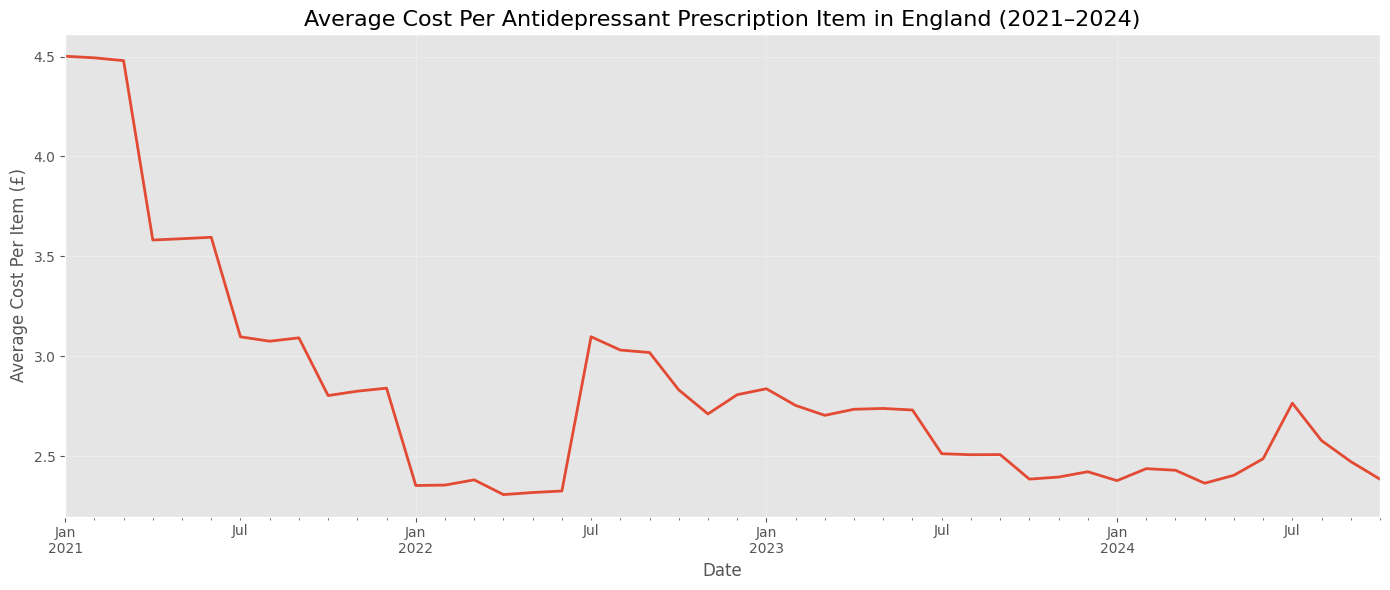

In [80]:
# Plot average cost per prescription item trend

plt.figure(figsize=(14,6))

monthly_summary['Cost_Per_Item'].plot(linewidth=2)

plt.title('Average Cost Per Antidepressant Prescription Item in England (2021–2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Cost Per Item (£)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../visuals/cost_per_item_trend.png")

plt.show()

### Interpretation

The average cost per prescription item decreased over time, supporting the observation that prescribing became more cost efficient during the study period.

This suggests that although antidepressant prescribing volumes increased, the average cost associated with each item reduced.

# Key Insights

## Prescribing Insights
- Sertraline hydrochloride was the most prescribed antidepressant.
- Prescribing volumes increased steadily between 2021 and 2024.

## Financial Insights
- Prescribing costs generally decreased over time.
- Venlafaxine generated disproportionately high prescribing costs.

## Regional Insights
- North East and Yorkshire recorded the highest prescribing activity.

# Conclusion

This project explored antidepressant prescribing patterns across NHS regions in England using NHSBSA prescribing data.

The analysis identified important prescribing trends, regional variations, and operational cost insights. Increasing prescribing volumes alongside decreasing prescribing costs suggest potential improvements in prescribing efficiency across the NHS.

This analysis demonstrated how healthcare prescribing data can be used to generate operational, financial, and regional insights using Python and exploratory data analysis techniques.

The findings highlight increasing antidepressant prescribing demand alongside improving prescribing cost efficiency across NHS regions.

# Project Reflection

This project strengthened my understanding of healthcare analytics, operational reporting, exploratory data analysis, and time-series analysis using real NHS prescribing data.

The analysis highlighted the importance of combining technical analysis with healthcare interpretation to generate meaningful operational insights from healthcare datasets.

# Recommendations

- Future analysis could investigate demographic and socioeconomic factors influencing prescribing variation.
- Forecasting models could be developed to predict future antidepressant prescribing demand.
- Additional NHS datasets could be integrated to analyse prescribing behaviour at GP practice level.
- Further investigation into high-cost medications may support prescribing optimisation initiatives.
- Develop forecasting models to predict future antidepressant prescribing demand.
- Develop forecasting models to predict future antidepressant prescribing demand and support operational healthcare planning.